In [35]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf # k线图
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

### 创建你的第一个量化策略
1. 参数设置：ticker 数据获取与标准化
2. 参数设置：captical, commission, benchmark
3. 策略与运行：indicators, signals
4. 策略与运行：cross-order, limit, pos, 涨跌停
5. 统计与验证：daily result (pnl)
6. 统计与验证：strategy statistics
7. 结果可视化：持仓收益、最大回撤、日盈亏
8. 结果可视化：市场基准（beta）对比

In [36]:
# 全局参数设置：工商银行为例
ticker = "601012.SS"
benchmark_ticker = "000001.SS"
start_date = "2025-09-30"
end_date = "2026-05-01"

#### 参数设置：ticker 数据获取与标准化
- 数据获取：yf.download(), 定义参数（股票代码、开始日期、结束日期、复权方式）
- 数据清洗：nan值 -> dropna
- 数据预览：整体看下数据

In [37]:
# 函数1：数据获取
def fetcher_data(ticker:str,start_date:str,end_date:str,auto_clean=True) -> pd.DataFrame:
    """ 获取数据 """
    try:
        print("正在获取历史数据：",ticker, start_date, end_date)
        data = yf.download(tickers=ticker,start=start_date,end=end_date,progress=False)
        # yfinance 个性化处理：去除第二行的列名，即ticker值
        data = data.droplevel(level=1,axis=1)
        print("完成数据获取，共有记录（条数）：", len(data))

        if auto_clean:
            clean_data(data)
    
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return pd.DataFrame

# 函数2：数据清洗
def clean_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 清洗数据：缺失值 """
    try:
        count_nan = data.isnull().sum().sum()
        print("当前data共有缺失值（个数）：",count_nan)
        data = data.dropna()
        count_nan = data.isnull().sum().sum()
        print("缺失值处理完毕，当前缺失值（个数）：",count_nan)
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return data

# 函数3：数据预览
def preview_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 按需要的格式预览数据 """
    print("数据预览：",data)

In [38]:
data = fetcher_data(ticker,start_date,end_date)
preview_data(data)

正在获取历史数据： 601012.SS 2025-09-30 2026-05-01
完成数据获取，共有记录（条数）： 138
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price           Close       High        Low       Open     Volume
Date                                                             
2025-09-30  18.000000  18.049999  17.459999  17.590000  169237697
2025-10-09  18.879999  19.110001  17.870001  18.049999  275340655
2025-10-10  18.400000  19.219999  18.260000  18.969999  188872474
2025-10-13  18.129999  18.290001  17.629999  17.650000  157447206
2025-10-14  19.280001  19.940001  18.400000  18.400000  556940097
...               ...        ...        ...        ...        ...
2026-04-24  17.389999  17.559999  17.260000  17.510000   97503657
2026-04-27  17.139999  17.430000  17.120001  17.299999  109004163
2026-04-28  16.950001  17.209999  16.889999  17.030001   97787267
2026-04-29  16.549999  16.590000  15.820000  16.280001  245595378
2026-04-30  16.459999  16.680000  16.370001  16.370001  131505381

[138 rows x 5 columns]


#### 参数设置：capital, commission, slippage, benchmark
- initial_capital：初始资金，决定能买多少股票，是收益率、仓位计算的基准，回测设置为尽可能大的整数（如100万）
- commission: 交易手续费（佣金 + 税费），总共约为千1，即0.1% -> 0.001
- slippage: 滑点（成交价偏差），实际成交价与理论信号价的偏差，反应市场流动性和成交延迟，回测过程中设置为万5，即0.05% -> 0.0005
- benchmark: 市场基准（beta），使用上证指数 000001.SS

In [39]:
# 全局交易参数设置
trading_config = {
    "initial_capital":1000000,
    "commission":0.001,
    "slippage":0.0005
}

In [40]:
benchmark_data = fetcher_data(benchmark_ticker,start_date,end_date)
preview_data(benchmark_data)

正在获取历史数据： 000001.SS 2025-09-30 2026-05-01
完成数据获取，共有记录（条数）： 138
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price             Close         High          Low         Open  Volume
Date                                                                  
2025-09-30  3882.777100  3887.570068  3866.281006  3869.705078  569700
2025-10-09  3933.971924  3936.575928  3885.743896  3898.306885  725200
2025-10-10  3897.028076  3933.004883  3886.304932  3915.475098  718900
2025-10-13  3889.501953  3895.830078  3800.104980  3800.104980  709500
2025-10-14  3865.229004  3918.436035  3851.121094  3910.781982  800800
...                 ...          ...          ...          ...     ...
2026-04-24  4079.899902  4092.613037  4061.145020  4081.032959  605000
2026-04-27  4086.343994  4092.831055  4071.080078  4074.811035  590000
2026-04-28  4078.636963  4090.200928  4062.872070  4076.143066  600500
2026-04-29  4107.514160  4112.151855  4061.822021  4061.822021  614200
2026-04-30  4112.159180  4118.754883  4

In [41]:
# 函数4：对比投资标的与市场基准的价格曲线
def plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data,auto_normalize=True):
    combined_data = pd.DataFrame({
        ticker: data['Close'],
        benchmark_ticker: benchmark_data['Close']
    })

    # 数据标准化（0~1）：解决价格差异太大导致无法直观对比的问题
    if auto_normalize:
        combined_data = combined_data / combined_data.iloc[0] * 100
        ylable = "相对涨幅（%）"
    else:
        ylable = "收盘价"

    combined_data.plot(figsize=(12,5), linewidth=2)
    plt.title(f"{ticker} vs {benchmark_ticker} 收盘价对比")
    plt.xlabel("日期")
    plt.ylabel(ylable)
    plt.grid(alpha=0.3)

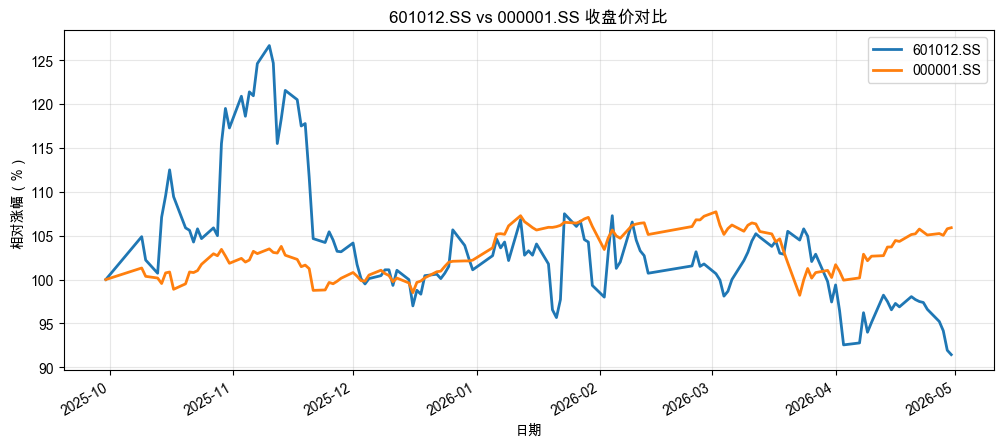

In [42]:
plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data)